# VRM / VRMA cross-check

Applies the Velocity Ring Model (VRM) and its azimuthally-resolved extension
(VRMA) to this galaxy's velocity field, using the vendored reference
implementation in `vrm/VRM_VRMA.py`
(https://github.com/MatteoStraccamore/VRM_VRMA), and compares the result
against this project's own `s1(R)` measurement from `harmonic_fit.py`.

Method: Sylos Labini, Straccamore, De Marzo & Comerón, "Mapping
non-axisymmetric velocity fields of external galaxies", ApJ 988, 122 (2025),
doi:10.3847/1538-4357/adc71c. See `vrm/README.md` for how VRM/VRMA differs
methodologically from this project's own pipeline, and for a real upstream
gotcha (`phi0input` is accepted but never used) that `vrm/bridge.py` works
around explicitly.

**The short version of the difference:** `harmonic_fit.py` fixes the
rotation curve at Barolo's `VROT` and fits only `c0` and `s1` (=`v_r`). VRM
fits `v_t` *and* `v_r` together, per ring, with nothing held fixed but the
global geometry -- and its rings are equal-width bins in *rescaled* radius
over the full detected extent, not the Barolo tilted-ring edges this
project's other notebook uses. VRM also has **no built-in error
quantification** -- every number below is a point estimate, unlike the
bootstrap + PA/VSYS-scan error budget in `harmonic_pipeline.ipynb`.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from astropy.table import Table

import harmonic_fit as hf
from harmonic_plots import custom_rcparams
from vrm.bridge import run_vrm

mpl.rcParams.update(custom_rcparams)
project_dir = Path.cwd()

## Geometry and data-quality cut

Reuses this project's own ringlog, maps, and data-quality mask
(`sigma_artifact_floor_kms`) rather than re-deriving them -- see
`CLAUDE.md` Section 5.3 for why the near-zero-`mom2` cut exists. `P.A.` and
`INC` are identical across all four rings in this ringlog (no warp), so one
global geometry is used for VRM, matching the tilted-ring model's own
assumption in the inner disk.

In [2]:
ringlog = hf.read_ringlog(project_dir / "stage_1_opt_parameters.txt")
mapset = hf.load_maps(project_dir / "maps")
cdelt1_sign = -1 if mapset.cdelt1_deg < 0 else (1 if mapset.cdelt1_deg > 0 else 0)

row0 = ringlog[0]
xc, yc = float(row0["XPOS(pix)"]), float(row0["YPOS(pix)"])
pa_deg, inc_deg = float(row0["P.A.(deg)"]), float(row0["INC(deg)"])
vsys_barolo = float(row0["VSYS(km/s)"])
sigma_artifact_floor_kms = 0.5  # same cut as harmonic_fit.Config's default

print(f"PA = {pa_deg} deg, INC = {inc_deg} deg, Barolo VSYS = {vsys_barolo} km/s")

PA = 53.445 deg, INC = 49.345 deg, Barolo VSYS = 4677.0 km/s


## VRM: one (v_t, v_r) per ring

`number_rings=4` to sit alongside this project's own 4-ring result -- but
note the x-axis below is **not** guaranteed to line up with the Barolo ring
edges, since VRM bins by rescaled radius over the full extent of the good
pixels, whatever that extent turns out to be.

In [3]:
result_vrm = run_vrm(mapset, xc, yc, pa_deg, inc_deg, cdelt1_sign, sigma_artifact_floor_kms,
                      number_rings=4, number_arch=1)

print(f"VRM-fit VSYS = {result_vrm['vsys_fit']:.2f} km/s  "
      f"(Barolo ringlog VSYS = {vsys_barolo:.2f} km/s, "
      f"difference = {result_vrm['vsys_fit'] - vsys_barolo:+.2f} km/s)")
print(f"{result_vrm['n_good_pixels']} good pixels used")

result_vrm["table"]

4682.719042871236
VRM-fit VSYS = 4682.72 km/s  (Barolo ringlog VSYS = 4677.00 km/s, difference = +5.72 km/s)
440 good pixels used


ring_index,arc_index,r_arcsec_mean,theta_mean,n_points,v_t,v_r
int64,int64,float64,float64,int64,float64,float64
0,0,41.37659501309917,2.291968272800253,54,277.01744703494353,-23.200620695388277
1,0,55.73531466018569,3.1772377492869177,213,303.13178919390134,-50.2898517123972
2,0,69.74292685004171,2.9303499221307687,162,313.44028846557046,-44.29587354168329
3,0,87.35965837942868,1.3146971977754194,10,439.10937835027784,-101.52060063617006


## v_t(R) vs. Barolo's VROT, and v_r(R) vs. this project's s1(R)

Marker size scales with `sqrt(n_points)` in each VRM bin -- a small marker
is a bin fit from very few pixels and should not be trusted. The outermost
VRM ring in particular can extend past where Barolo's rings (and this
project's own analysis) stop, into much sparser territory.

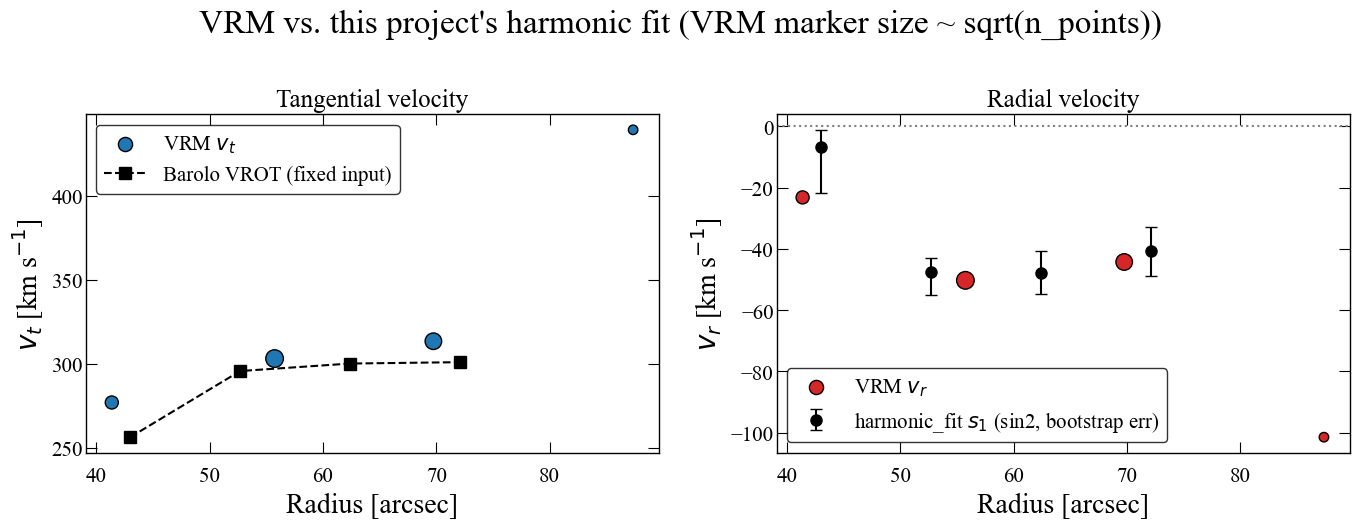

In [4]:
harm_table = Table.read(project_dir / "results" / "ring_results.ecsv", format="ascii.ecsv")
primary_weighting = harm_table.meta["primary_weighting"]
harm_both = harm_table[(harm_table["side"] == "both") & (harm_table["weighting"] == primary_weighting)]
harm_both.sort("ring_index")
r_arcsec_ours = (harm_both["r_in_arcsec"] + harm_both["r_out_arcsec"]) / 2.0

t = result_vrm["table"]
sizes = 15 + 10 * np.sqrt(t["n_points"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

ax1.scatter(t["r_arcsec_mean"], t["v_t"], s=sizes, c="tab:blue", edgecolor="black", label="VRM $v_t$", zorder=3)
ax1.plot(r_arcsec_ours, harm_both["vrot_kms"], "s--", color="black", label="Barolo VROT (fixed input)")
ax1.set_xlabel("Radius [arcsec]")
ax1.set_ylabel(r"$v_t$ [km s$^{-1}$]")
ax1.legend()
ax1.set_title("Tangential velocity")

ax2.scatter(t["r_arcsec_mean"], t["v_r"], s=sizes, c="tab:red", edgecolor="black", label="VRM $v_r$", zorder=3)
ax2.errorbar(r_arcsec_ours, harm_both["s1"],
             yerr=[harm_both["s1"] - harm_both["s1_boot_lo"], harm_both["s1_boot_hi"] - harm_both["s1"]],
             fmt="o", color="black", capsize=4, label=f"harmonic_fit $s_1$ ({primary_weighting}, bootstrap err)", zorder=4)
ax2.axhline(0, color="gray", linestyle=":")
ax2.set_xlabel("Radius [arcsec]")
ax2.set_ylabel(r"$v_r$ [km s$^{-1}$]")
ax2.legend()
ax2.set_title("Radial velocity")

fig.suptitle("VRM vs. this project's harmonic fit (VRM marker size ~ sqrt(n_points))")
fig.tight_layout()
None

## VRMA: azimuthally-resolved v_r(R, theta)

Splitting each ring into arcs trades points-per-bin for angular resolution.
Given how patchy this data's azimuthal coverage already is at the per-ring
level (see `fig_coverage` in `harmonic_pipeline.ipynb`), most bins at even
modest resolution end up under-constrained -- shown explicitly via
`n_points` rather than smoothed over. Bins with fewer than 3 points (an
under- or exactly-determined 2-parameter fit) are greyed out.

In [5]:
result_vrma = run_vrm(mapset, xc, yc, pa_deg, inc_deg, cdelt1_sign, sigma_artifact_floor_kms,
                       number_rings=4, number_arch=4)
t2 = result_vrma["table"]

n_total = len(t2)
n_unreliable = int(np.sum(t2["n_points"] < 3))
print(f"{n_unreliable} / {n_total} (ring, arc) bins have fewer than 3 points")

t2["ring_index", "arc_index", "r_arcsec_mean", "n_points", "v_t", "v_r"]

4682.719042871236
2 / 16 (ring, arc) bins have fewer than 3 points


ring_index,arc_index,r_arcsec_mean,n_points,v_t,v_r
int64,int64,float64,int64,float64,float64
0,0,39.726904025166235,30,248.01871728727383,-8.996044106340763
0,1,42.80494729287467,7,297.2442337765011,9.736868891213135
0,2,43.635953695230505,9,274.0289650359281,-3.0484133537525793
0,3,43.77134945564626,8,268.8154731327477,-114.88372253888508
1,0,55.18578103935578,62,275.13224289207415,-23.675468396797363
1,1,56.331577963325074,37,313.32979762976936,-37.60418694091628
1,2,55.69822673838983,58,309.36336419181464,-46.44105533275378
1,3,55.98817969124745,56,280.63656457621414,-85.65209762366219
2,0,71.31893835734759,66,289.115370143065,-23.61781525270338


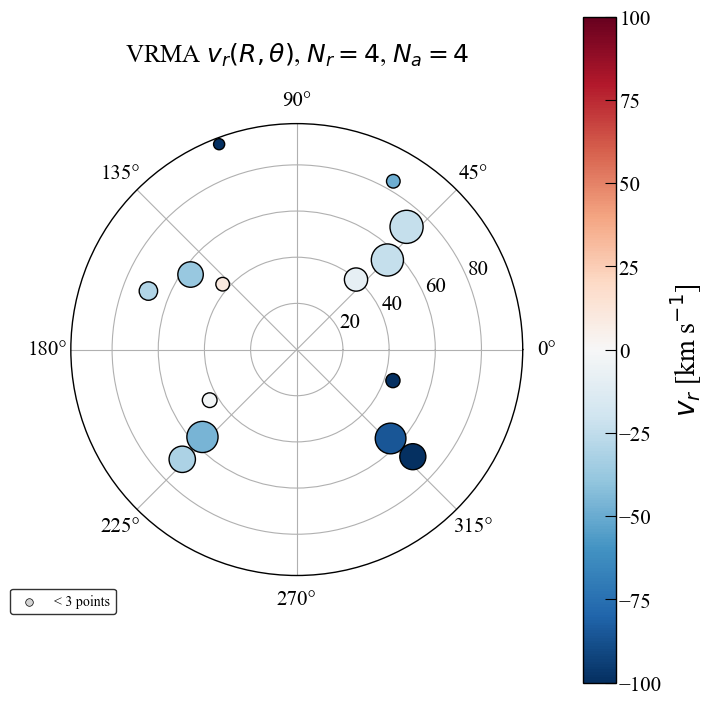

In [6]:
reliable = np.asarray(t2["n_points"]) >= 3
marginal = (np.asarray(t2["n_points"]) > 0) & ~reliable

fig, ax = plt.subplots(figsize=(7.5, 7.5), subplot_kw=dict(projection="polar"))

ax.scatter(t2["theta_mean"][marginal], t2["r_arcsec_mean"][marginal],
           s=30, c="lightgray", edgecolor="black", linewidth=0.5, zorder=2, label="< 3 points")
sc = ax.scatter(t2["theta_mean"][reliable], t2["r_arcsec_mean"][reliable],
                 c=t2["v_r"][reliable], s=40 + 8 * t2["n_points"][reliable],
                 cmap="RdBu_r", vmin=-100, vmax=100, edgecolor="black", zorder=3)

fig.colorbar(sc, ax=ax, label=r"$v_r$ [km s$^{-1}$]", pad=0.1)
ax.legend(loc="lower left", bbox_to_anchor=(-0.15, -0.1), fontsize=10)
ax.set_title("VRMA $v_r(R,\\theta)$, $N_r=4$, $N_a=4$", pad=20)
fig.tight_layout()
None

## Summary

- VRM's independently-fit systemic velocity and this project's Barolo-ringlog
  `VSYS` should agree closely if the two methods' geometry assumptions are
  compatible; a large discrepancy is itself informative.
- The `v_t(R)` comparison is a sanity check on VRM's geometry, not a new
  result -- Barolo's `VROT` was held fixed as an *input* to `harmonic_fit.py`,
  so close agreement there is closer to "necessary" than "confirmatory";
  VRM fits it independently, and its rings extend past this project's own
  fitted radius range, into territory Barolo's tilted-ring model was never
  asked to cover either.
- The `v_r(R)` comparison is the actual cross-check: VRM makes no assumption
  about `VROT`, uses a different radial binning, and has entirely different
  systematics (no PA-degeneracy handling, no bootstrap) from this project's
  `s1(R)`. Agreement between the two, within VRM's un-quantified point-to-point
  scatter, is independent support for the radial-motion detection; disagreement
  points at systematics specific to one method rather than the other.
- Take every VRM/VRMA point estimate with its `n_points` in hand -- the
  method returns a number even from an empty or near-empty bin (see
  `vrm/README.md`), and this dataset's coverage is patchy enough that this
  happens often once arcs are introduced.